In [2]:
import numpy as np
import matplotlib

%matplotlib inline

In [24]:
def fetch(url: str):
    import requests, gzip, os, hashlib, numpy as np

    fp = os.path.join("/tmp", hashlib.md5(url.encode('utf-8')).hexdigest())

    if os.path.isfile(fp):
        with open(fp, 'rb') as f:
            dat = f.read()
    else:
        r = requests.get(
            url.replace("http://", "https://"),
            headers={"User-Agent": "Mozilla/5.0"},
            timeout=10
        )
        r.raise_for_status()
        dat = r.content

        with open(fp, 'wb') as f:
            f.write(dat)

    return np.frombuffer(gzip.decompress(dat), dtype=np.uint8).copy()

In [ ]:
BASE = "https://storage.googleapis.com/cvdf-datasets/mnist/"

X_train = fetch(BASE + "train-images-idx3-ubyte.gz")[0x10:].reshape(-1, 28, 28)
Y_train = fetch(BASE + "train-labels-idx1-ubyte.gz")[8:]
X_test  = fetch(BASE + "t10k-images-idx3-ubyte.gz")[0x10:].reshape(-1, 28, 28)
Y_test  = fetch(BASE + "t10k-labels-idx1-ubyte.gz")[8:]

X_train = X_train / 255.0
X_test = X_test / 255.0

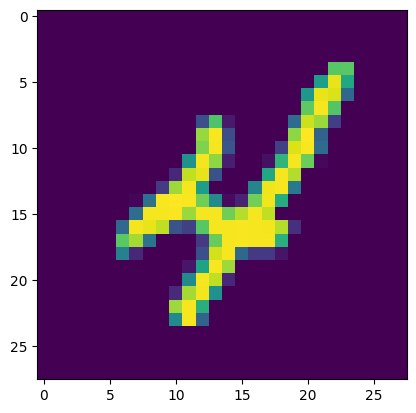

In [94]:
imshow(X_train[9])

In [21]:
import torch
import torch.nn as nn

In [82]:
class BobNet(nn.Module):
    def __init__(self):
        super(BobNet, self).__init__()
        self.l1 = nn.Linear(784, 128)
        self.act = nn.ReLU()
        self.l2 = nn.Linear(128, 10)
    def forward(self, x):
        x = self.l1(x)
        x = self.act(x)
        x = self.l2(x)

        return x

model = BobNet()

BS = 32

lossfn = nn.CrossEntropyLoss()

optim = torch.optim.Adam(model.parameters())

losses, accs = [], []

for i in range(1000):
    optim.zero_grad()
    samp = np.random.randint(0, X_train.shape[0], size=(BS))
    X = torch.tensor(X_train[samp].reshape((-1, 28*28))).float()
    Y = torch.tensor(Y_train[samp]).long()

    out = model(X)
    cat = torch.argmax(out, dim=1)
    accuracy = (cat == Y).float().mean()
    loss = lossfn(out, Y)

    loss.backward()

    optim.step()
    loss, accuracy = loss.item(), accuracy.item()
    losses.append(loss)
    accs.append(accuracy)

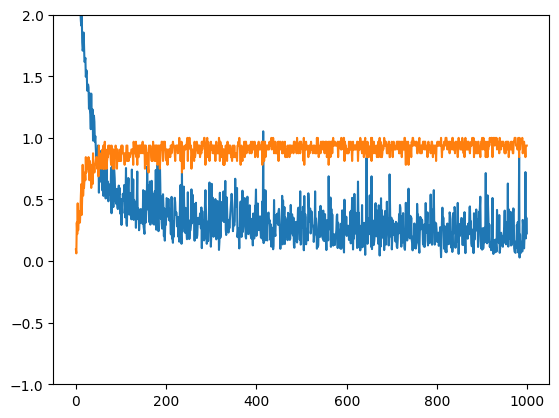

In [83]:
plt.ylim(-1, 2)
plot(losses)
plot(accs)

In [84]:
preds = torch.argmax(model(torch.tensor(X_test).reshape((-1, 28*28)).float()), dim=1).numpy()
(Y_test == preds).mean()

np.float64(0.9387)